# Recyclage et territoire : à la recherche d'un profil écologique géographique ?

## Problématique

Les questions écologiques constituent une thématique importante notamment dans la gestion des territoires. Partant de ce constat, nous avons cherché un indicateur de comportement écologique que l'on pourrait croiser avec des données géographiques liés à la population francaise. Nous avons donc décidé de nous interesser à la **valorisation des déchets ménagers et assimilés (DMA)**. 

Nous allons montrer que cette valorisation n'est pas la même au sein de la France métropolitaine. En effet, les performances de valorisation varient considérablement d'un département à l'autre. Quels facteurs territoriaux et socio-économiques expliquent ces disparités ?

Ce notebook explore deux hypothèses principales :
1. **Hypothèse territoriale** : les départements ruraux, bénéficiant d'une gestion différente des déchets (compostage, valorisation organique), présenteraient de meilleurs taux de valorisation.
2. **Hypothèse socio-économique** : les départements plus aisés investiraient davantage dans les infrastructures de tri et de recyclage.

Nous nous sommes aussi intéressés aux deux composantes de la valorisation :
- ** Valorisation de la matière ** : recyclage
- ** Valorisation organique ** : compostage et méthanisation

## Données utilisées

| Source | Fichier | Description |
|--------|---------|-------------|
| ADEME / SINOE | `SINOE04_DestinationDmaParTypeTraitement.csv` | Tonnages de déchets par type de traitement et département |
| INSEE | `FET2021-19.xlsx` | Grille de densité communale (urbain/rural) |
| INSEE | `niv2021.xlsx` | Niveau de vie médian annuel par département(légèrement revu, les 3 premiers lignes ont été supprimées |

> **Reproductibilité** : les fichiers de données doivent être placés dans le même répertoire que ce notebook. Les sources sont disponibles sur [data.ademe.fr](https://data.ademe.fr) et [insee.fr](https://insee.fr).

## Plan
0. Packages et impots
1. Chargement et nettoyage des données
2. Analyse descriptive
3. Visualisations : distributions, nuages de points, cartes
4. Modélisation : corrélations et régression multiple
5. Conclusion

## 0. Quelques package necessaires : 

Installer les packages avec le fichier requirement 

In [1]:
%pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 84.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 89.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 607.2/607.2 kB 29.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [great_tables] [great_tables]
Note: you may need to restart the kernel to use updated packages.


In [2]:
# ── Imports ────────────────────────────────────────────────────────────────────
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import statsmodels.api as sm
import numpy as np
import requests
from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from io import StringIO
from fonctions import scatter_regression
from fonctions import attribuer_profil
from fonctions import afficher_correlations
from fonctions import regression_ols
from fonctions import diagnostics_ols


# ── Paramètres globaux ─────────────────────────────────────────────────────────
# dpi=120 : résolution des figures (120 points par pouce, plus net que le défaut)
plt.rcParams["figure.dpi"] = 120
# whitegrid : fond blanc avec grille légère ; palette "muted" : couleurs douces
sns.set_theme(style="whitegrid", palette="muted")

# URL du fond de carte GeoJSON 
# contours des 96 départements métropolitains
GEOJSON_URL = "https://france-geojson.gregoiredavid.fr/repo/departements.geojson"

print("Imports OK")

Imports OK


## 1. Chargement et nettoyage des données

### RECUPERATIONS DES DONNEES AVEC LES API

In [3]:
# Récupération des données ADEME (URL direct)
# URL directe du fichier CSV ADEME sur data.ademe.fr
ADEME_CSV_URL = (
    "https://data.ademe.fr/data-fair/api/v1/datasets/"
    "sinoe-(r)-destination-des-dma-collectes-par-type-de-traitement/"
    "data-files/SINOE04_DestinationDmaParTypeTraitement.csv"
)
response = requests.get(ADEME_CSV_URL)
response.raise_for_status()
# StringIO permet de lire le texte téléchargé comme si c'était un fichier
# sep=None + engine='python' : détection automatique du séparateur
df = pd.read_csv(StringIO(response.text), sep=None, engine="python")
print(f"Fichier ADEME chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes")

df_ademe = df.copy()
df_ademe.head()

Fichier ADEME chargé : 14660 lignes × 10 colonnes


,ANNEE,C_REGION,L_REGION,C_DEPT,N_DEPT,C_TYP_REG_DECHET,L_TYP_REG_DECHET,C_TYP_REG_SERVICE,L_TYP_REG_SERVICE,TONNAGE_DMA
0,2009,84,Auvergne-Rhône-Alpes,01,Ain,07A,Ordures ménagères résiduelles,02B,Incinération avec récupération d'énergie,"98575,13"
1,2009,84,Auvergne-Rhône-Alpes,01,Ain,07A,Ordures ménagères résiduelles,02D,Stockage,"35633,56"
2,2009,84,Auvergne-Rhône-Alpes,01,Ain,07E,Matériaux recyclables,02A,Valorisation matière,"61734,13"
3,2009,84,Auvergne-Rhône-Alpes,01,Ain,07E,Matériaux recyclables,02E,Valorisation organique,"5460,17"
4,2009,84,Auvergne-Rhône-Alpes,01,Ain,07E,Matériaux recyclables,02B,Incinération avec récupération d'énergie,"831,58"


### 1.1 Données SINOE (déchets)
 Le fichier SINOE recense les tonnages de DMA par département, par année
 et par **type de traitement**. Les types disponibles sont :
 - Valorisation matière ← recyclage
 - Valorisation organique ← compostage / méthanisation
 - Incinération avec/sans récupération d'énergie
 - Stockage
 - autre


In [4]:
 # Étape 1 : aperçu des données brutes
print(f"Dimensions brutes : {df_ademe.shape}")
print(f"Années disponibles : {sorted(df_ademe['ANNEE'].unique())}")
print(f"Types de traitement : {df_ademe['L_TYP_REG_SERVICE'].unique().tolist()}")


Dimensions brutes : (14660, 10)
Années disponibles : [np.int64(2009), np.int64(2011), np.int64(2013), np.int64(2015), np.int64(2017), np.int64(2019), np.int64(2021)]
Types de traitement : ["Incinération avec récupération d'énergie", 'Stockage', 'Valorisation matière', 'Valorisation organique', 'Non précisé', 'Stockage pour inertes', "Incinération sans récupération d'énergie"]


### Verification de la presence des valeurs manquantes

In [5]:
df_ademe.isna().sum()

ANNEE                0
C_REGION             0
L_REGION             0
C_DEPT               0
N_DEPT               0
C_TYP_REG_DECHET     0
L_TYP_REG_DECHET     0
C_TYP_REG_SERVICE    0
L_TYP_REG_SERVICE    0
TONNAGE_DMA          0
dtype: int64

CONSTAT: PAS DE VALEURS MANQUANTES

In [6]:

    # Étape 2 : nettoyage du tonnage (virgule → point pour Python)
df_ademe["TONNAGE_DMA"] = (
        df_ademe["TONNAGE_DMA"]
        .astype(str)                         
        .str.replace(",", ".", regex=False)  # "98575,13" → "98575.13"
        .astype(float)                       # conversion en nombre décimal
    )


In [7]:
# Étape 3 : codes département sur 2 caractères pour les jointures et renommer la colonne departement
df_ademe["code_dept"] = df_ademe["C_DEPT"].astype(str).str.zfill(2)
df_ademe["departement"] = df_ademe["N_DEPT"]


In [8]:
# Étape 4 : conserver uniquement la dernière année disponible
annee_max = df_ademe["ANNEE"].max()
df_ademe = df_ademe[df_ademe["ANNEE"] == annee_max].copy()
print(f"\nAnnée retenue : {annee_max}  ({len(df)} lignes après filtre)")



Année retenue : 2021  (14660 lignes après filtre)


In [9]:
# Étape 5 : marquage des lignes par type de valorisation
    # Deux colonnes booléennes (True/False) pour distinguer les composantes
df_ademe["est_valo_matiere"] = df_ademe["L_TYP_REG_SERVICE"] == "Valorisation matière"
df_ademe["est_valo_organique"] = df_ademe["L_TYP_REG_SERVICE"] == "Valorisation organique"

# Colonnes de tonnage conditionnelles créées avant le groupby.
# where(condition, 0) : garde le tonnage si la condition est vraie, sinon 0.
df_ademe["tonnage_si_matiere"] = df_ademe["TONNAGE_DMA"].where(df_ademe["est_valo_matiere"], 0)
df_ademe["tonnage_si_organique"] = df_ademe["TONNAGE_DMA"].where(df_ademe["est_valo_organique"], 0)


In [10]:

    # Étape 6 : agrégation par département
dept = (
        df_ademe.groupby(["code_dept", "departement"], as_index=False)
        .agg(
            tonnage_total=("TONNAGE_DMA", "sum"),
            tonnage_valo_matiere=("tonnage_si_matiere", "sum"),
            tonnage_valo_organique=("tonnage_si_organique", "sum"),
        )
    )

In [11]:
# Calcul des taux de valorisation (en %)
    # Taux = tonnage valorisé / tonnage total × 100
dept["tonnage_valo_total"] = dept["tonnage_valo_matiere"] + dept["tonnage_valo_organique"]
dept["taux_valo_total_pct"] = dept["tonnage_valo_total"] / dept["tonnage_total"] * 100
dept["taux_valo_matiere_pct"] = dept["tonnage_valo_matiere"] / dept["tonnage_total"] * 100
dept["taux_valo_organique_pct"] = dept["tonnage_valo_organique"] / dept["tonnage_total"] * 100

print(f"{len(dept)} départements après agrégation")

99 départements après agrégation


In [12]:
# Appel de la fonction charger_sinoe
sinoe_dept = dept.copy()
display(sinoe_dept.head())

,code_dept,departement,tonnage_total,tonnage_valo_matiere,tonnage_valo_organique,tonnage_valo_total,taux_valo_total_pct,taux_valo_matiere_pct,taux_valo_organique_pct
0,01,Ain,383489.91,139897.47,77012.73,216910.20,56.562166,36.480091,20.082075
1,02,Aisne,328139.23,100389.96,40931.54,141321.50,43.067542,30.593709,12.473833
2,03,Allier,211885.62,61220.51,30746.28,91966.79,43.403979,28.893188,14.510791
3,04,Alpes-de-Haute-Provence,136286.08,40255.77,15084.65,55340.42,40.606069,29.537697,11.068372
4,05,Hautes-Alpes,98738.31,37296.24,5164.97,42461.21,43.003784,37.772816,5.230969


### 1.2 Données FET (ruralité)

La grille de densité classe chaque commune en 4 catégories:
Commnune densément peuplée, densité intermédiaire, peu dense et très peu dense. On considère les deux dernières comme rurale.

On utilise comme indicateur la part de communes rurales dans le département.




In [13]:
df_dept = pd.read_excel("https://minio.lab.sspcloud.fr/id2848/FET2021-19.xlsx", sheet_name="Figure 1", skiprows=2)
df_dept.head(5)

,Code commune,Libellé commune,Libellé région,Libellé typologie
0,01001,L'Abergement-Clémenciat,Auvergne-Rhône-Alpes,Communes peu denses
1,01002,L'Abergement-de-Varey,Auvergne-Rhône-Alpes,Communes très peu denses
2,01004,Ambérieu-en-Bugey,Auvergne-Rhône-Alpes,Communes de densité intermédiaire
3,01005,Ambérieux-en-Dombes,Auvergne-Rhône-Alpes,Communes peu denses
4,01006,Ambléon,Auvergne-Rhône-Alpes,Communes très peu denses


In [14]:

df_dept.columns = ["code_commune", "lib_commune", "code_typologie", "lib_typologie"]
print(f"{len(df_dept)} communes chargées")
print(f"Typologies : {df_dept['lib_typologie'].unique().tolist()}")

# Codes communes sur 5 caractères
df_dept["code_commune"] = df_dept["code_commune"].astype(str).str.zfill(5)

# Code département = 2 premiers caractères du code commune
df_dept["code_dept"] = df_dept["code_commune"].str[:2]

# Identification des communes rurales
types_ruraux = ["Communes peu denses", "Communes très peu denses"]
df_dept["est_rural"] = df_dept["lib_typologie"].isin(types_ruraux)

    # Agrégation par département
ruralite_dept = (
        df_dept.groupby("code_dept", as_index=False)
        .agg(
            nb_communes=("code_commune", "count"),
            nb_communes_rurales=("est_rural", "sum"),
        )
    )

# Part des communes rurales
ruralite_dept["part_communes_rurales_pct"] = (
        ruralite_dept["nb_communes_rurales"] / ruralite_dept["nb_communes"] * 100
    )

print(f"{len(ruralite_dept)} départements après agrégation")

34970 communes chargées
Typologies : ['Communes peu denses', 'Communes très peu denses', 'Communes de densité intermédiaire', 'Communes densément peuplées', nan]
99 départements après agrégation


In [15]:

display(ruralite_dept.head())

,code_dept,nb_communes,nb_communes_rurales,part_communes_rurales_pct
0,01,393,328,83.460560
1,02,800,757,94.625000
2,03,317,303,95.583596
3,04,198,187,94.444444
4,05,162,157,96.913580


### 1.3 Données INSEE (niveau de vie médian)

In [16]:

revenu_dept = pd.read_excel("https://minio.lab.sspcloud.fr/id2848/niv2021.xlsx", sheet_name="Territoire - Figure 1")
print(f"Colonnes disponibles : {revenu_dept.columns.tolist()}")
print(f"Dimensions : {revenu_dept.shape}")

revenu_dept = revenu_dept.rename(columns={
        "Code département": "code_dept",
        "Département": "departement_rev",
        "Niveau de vie annuel médian": "niveau_vie_median",
    })

# Codes département sur 2 caractères
revenu_dept["code_dept"] = revenu_dept["code_dept"].astype(str).str.zfill(2)

# Conversion numérique : valeurs non numériques enregistrées comme NaN
revenu_dept["niveau_vie_median"] = pd.to_numeric(revenu_dept["niveau_vie_median"], errors="coerce")

print(f"\nValeurs manquantes sur niveau_vie_median : {revenu_dept['niveau_vie_median'].isna().sum()}")
display(revenu_dept.head())


Colonnes disponibles : ['Code département', 'Département', 'Niveau de vie annuel médian']
Dimensions : (105, 3)

Valeurs manquantes sur niveau_vie_median : 4


,code_dept,departement_rev,niveau_vie_median
0,01,Ain,24810.0
1,02,Aisne,20920.0
2,03,Allier,21500.0
3,04,Alpes-de-Haute-Provence,21790.0
4,05,Hautes-Alpes,22010.0


### 1.4 Jointure des trois sources

In [17]:
# Jointures successives 
# inner join SINOE + ruralité : on ne garde que les depts présents dans les deux
# left join + revenu : on conserve tous les depts même si le revenu est manquant

df = (
    sinoe_dept
    .merge(ruralite_dept, on="code_dept", how="inner")
    .merge(revenu_dept[["code_dept", "niveau_vie_median"]], on="code_dept", how="left")
)

print(f"Table finale : {len(df)} départements")


Table finale : 96 départements


In [18]:
df.head(5)

,code_dept,departement,tonnage_total,tonnage_valo_matiere,tonnage_valo_organique,tonnage_valo_total,taux_valo_total_pct,taux_valo_matiere_pct,taux_valo_organique_pct,nb_communes,nb_communes_rurales,part_communes_rurales_pct,niveau_vie_median
0,01,Ain,383489.91,139897.47,77012.73,216910.20,56.562166,36.480091,20.082075,393,328,83.460560,24810.0
1,02,Aisne,328139.23,100389.96,40931.54,141321.50,43.067542,30.593709,12.473833,800,757,94.625000,20920.0
2,03,Allier,211885.62,61220.51,30746.28,91966.79,43.403979,28.893188,14.510791,317,303,95.583596,21500.0
3,04,Alpes-de-Haute-Provence,136286.08,40255.77,15084.65,55340.42,40.606069,29.537697,11.068372,198,187,94.444444,21790.0
4,05,Hautes-Alpes,98738.31,37296.24,5164.97,42461.21,43.003784,37.772816,5.230969,162,157,96.913580,22010.0


#### Calcul d'une variable d'interaction ruralité × niveau de vie 

In [19]:
# Terme d'interaction ruralité × niveau de vie 
# Produit des deux variables explicatives.
# Il teste si l'effet de la ruralité sur la valorisation varie selon le revenu.
# Si son coefficient est non significatif alors les deux effets sont indépendants.
df["interaction_rural_revenu"] = df["part_communes_rurales_pct"] * df["niveau_vie_median"]

display(df.head())


,code_dept,departement,tonnage_total,tonnage_valo_matiere,tonnage_valo_organique,tonnage_valo_total,taux_valo_total_pct,taux_valo_matiere_pct,taux_valo_organique_pct,nb_communes,nb_communes_rurales,part_communes_rurales_pct,niveau_vie_median,interaction_rural_revenu
0,01,Ain,383489.91,139897.47,77012.73,216910.20,56.562166,36.480091,20.082075,393,328,83.460560,24810.0,2.070656e+06
1,02,Aisne,328139.23,100389.96,40931.54,141321.50,43.067542,30.593709,12.473833,800,757,94.625000,20920.0,1.979555e+06
2,03,Allier,211885.62,61220.51,30746.28,91966.79,43.403979,28.893188,14.510791,317,303,95.583596,21500.0,2.055047e+06
3,04,Alpes-de-Haute-Provence,136286.08,40255.77,15084.65,55340.42,40.606069,29.537697,11.068372,198,187,94.444444,21790.0,2.057944e+06
4,05,Hautes-Alpes,98738.31,37296.24,5164.97,42461.21,43.003784,37.772816,5.230969,162,157,96.913580,22010.0,2.133068e+06


## 2. Analyse descriptive

Avant toute modélisation, cette section présente une vue d'ensemble des trois variables principales.

In [21]:
#  Statistiques descriptives 
cols_cles = [
    "taux_valo_total_pct", "taux_valo_matiere_pct", "taux_valo_organique_pct",
    "part_communes_rurales_pct", "niveau_vie_median",
]
stats = df[cols_cles].describe().round(2)
stats = df[cols_cles].describe().round(2)
stats.index.name = "Statistique"
display(stats)

,taux_valo_total_pct,taux_valo_matiere_pct,taux_valo_organique_pct,part_communes_rurales_pct,niveau_vie_median
Statistique,,,,,
count,96.00,96.00,96.00,96.00,96.00
mean,49.42,34.22,15.20,83.97,22706.67
std,9.78,7.16,6.96,21.79,1721.89
min,29.33,21.99,0.15,0.00,19020.00
25%,43.34,29.53,10.90,82.23,21575.00
50%,47.89,34.07,14.26,92.84,22285.00
75%,53.70,38.62,18.93,95.94,23292.50
max,87.60,65.10,33.31,99.61,29730.00


**Lecture du tableau :**
Le taux de valorisation moyen est d'environ **49 %** avec une dispersion importante (écart-type ~10 pts, min 29 % – max 88 %), signe de fortes inégalités inter-départementales.
La part de communes rurales est très élevée en moyenne (84 %), mais la distribution est très asymétrique : la médiane est à 93 %, ce qui reflète une France majoritairement rurale en nombre de communes, avec quelques grands départements urbains qui tirent la moyenne vers le bas (min = 0 pour Paris).
Le niveau de vie médian est le plus concentré des trois (std = 1722 €, soit ~8 % de la moyenne), ce qui limite son pouvoir discriminant dans la régression — les départements sont relativement homogènes sur ce plan.

In [22]:
print("Top 10 — taux de valorisation le plus élevé")
display(
    df[["code_dept", "departement",
        "taux_valo_total_pct", "taux_valo_matiere_pct", "taux_valo_organique_pct",
        "part_communes_rurales_pct"]]
    .sort_values("taux_valo_total_pct", ascending=False)
    .head(10).round(2).reset_index(drop=True)
)


Top 10 — taux de valorisation le plus élevé


,code_dept,departement,taux_valo_total_pct,taux_valo_matiere_pct,taux_valo_organique_pct,part_communes_rurales_pct
0,85,Vendée,87.60,65.10,22.50,93.41
1,71,Saône-et-Loire,73.28,50.48,22.80,93.98
2,64,Pyrénées-Atlantiques,72.06,38.75,33.31,89.01
3,16,Charente,71.25,42.87,28.38,95.63
4,79,Deux-Sèvres,70.23,39.15,31.08,94.92
5,17,Charente-Maritime,65.86,44.83,21.03,91.79
6,34,Hérault,65.50,33.93,31.57,77.49
7,40,Landes,65.33,37.40,27.94,94.19
8,43,Haute-Loire,62.48,47.95,14.53,94.16
9,22,Cotes-d'Armor,60.03,34.40,25.63,92.82


In [23]:
print("\nTop 10 (des plus bas) — taux de valorisation le plus bas")
display(
    df[["code_dept", "departement",
        "taux_valo_total_pct", "taux_valo_matiere_pct", "taux_valo_organique_pct",
        "part_communes_rurales_pct"]]
    .sort_values("taux_valo_total_pct", ascending=True)
    .head(10).round(2).reset_index(drop=True)
)


Top 10 (des plus bas) — taux de valorisation le plus bas


,code_dept,departement,taux_valo_total_pct,taux_valo_matiere_pct,taux_valo_organique_pct,part_communes_rurales_pct
0,75,Paris,29.33,29.18,0.15,0.00
1,93,Seine-Saint-Denis,30.25,27.07,3.18,0.00
2,94,Val-de-Marne,31.00,24.51,6.49,0.00
3,2A,Corse-du-Sud,31.11,25.33,5.78,98.39
4,92,Hauts-de-seine,32.82,30.54,2.27,0.00
5,52,Haute-Marne,35.13,24.89,10.25,98.59
6,77,Seine-et-Marne,36.03,23.48,12.56,71.99
7,95,Val-d'Oise,36.20,26.99,9.21,47.83
8,66,Pyrénées-Orientales,38.65,26.42,12.22,81.42
9,13,Bouches-du-Rhône,39.55,28.70,10.85,38.66


**Analyse :** les départements en tête de classement sont majoritairement ruraux, ce qui va dans le sens de l'hypothèse territoriale. Les derniers du classement sont souvent des départements à forte concentration urbaine.
On peut regarder ce que cela donne en séparant les deux types de valorisation.
 

In [24]:
#  valorisation MATIÈRE (recyclage) ────────────────────────────────
print("Top 10 — valorisation matière (recyclage)")
display(
    df[["code_dept", "departement", "taux_valo_matiere_pct", "taux_valo_organique_pct"]]
    .sort_values("taux_valo_matiere_pct", ascending=False)
    .head(10).round(2).reset_index(drop=True)
)


Top 10 — valorisation matière (recyclage)


,code_dept,departement,taux_valo_matiere_pct,taux_valo_organique_pct
0,85,Vendée,65.10,22.50
1,24,Dordogne,51.89,5.26
2,71,Saône-et-Loire,50.48,22.80
3,43,Haute-Loire,47.95,14.53
4,48,Lozère,46.94,6.69
5,17,Charente-Maritime,44.83,21.03
6,12,Aveyron,44.20,7.78
7,39,Jura,43.61,9.32
8,16,Charente,42.87,28.38
9,70,Haute-Saône,42.74,15.64


In [25]:
print("Top 10 les plus bas— valorisation matière (recyclage)")
display(
    df[["code_dept", "departement", "taux_valo_matiere_pct", "taux_valo_organique_pct"]]
    .sort_values("taux_valo_matiere_pct", ascending=True)
    .head(10).round(2).reset_index(drop=True)
)


Top 10 les plus bas— valorisation matière (recyclage)


,code_dept,departement,taux_valo_matiere_pct,taux_valo_organique_pct
0,76,Seine-Maritime,21.99,24.62
1,80,Somme,22.15,31.77
2,77,Seine-et-Marne,23.48,12.56
3,94,Val-de-Marne,24.51,6.49
4,28,Eure-et-Loir,24.83,18.59
5,52,Haute-Marne,24.89,10.25
6,90,Territoire-de-Belfort,24.92,21.69
7,41,Loir-et-Cher,25.26,18.08
8,2A,Corse-du-Sud,25.33,5.78
9,14,Calvados,25.74,21.20


In [26]:
#  valorisation ORGANIQUE (compostage) ─────────────────────────────
print("Top 10 — valorisation organique (compostage / méthanisation)")
display(
    df[["code_dept", "departement", "taux_valo_matiere_pct", "taux_valo_organique_pct"]]
    .sort_values("taux_valo_organique_pct", ascending=False)
    .head(10).round(2).reset_index(drop=True)
)


Top 10 — valorisation organique (compostage / méthanisation)


,code_dept,departement,taux_valo_matiere_pct,taux_valo_organique_pct
0,64,Pyrénées-Atlantiques,38.75,33.31
1,80,Somme,22.15,31.77
2,34,Hérault,33.93,31.57
3,79,Deux-Sèvres,39.15,31.08
4,56,Morbihan,30.37,29.04
5,16,Charente,42.87,28.38
6,40,Landes,37.40,27.94
7,29,Finistère,29.81,27.60
8,22,Cotes-d'Armor,34.40,25.63
9,76,Seine-Maritime,21.99,24.62


In [27]:
print("Top 10 (les plus bas)— valorisation organique (compostage / méthanisation)")
display(
    df[["code_dept", "departement", "taux_valo_matiere_pct", "taux_valo_organique_pct"]]
    .sort_values("taux_valo_organique_pct", ascending=True)
    .head(10).round(2).reset_index(drop=True)
)

Top 10 (les plus bas)— valorisation organique (compostage / méthanisation)


,code_dept,departement,taux_valo_matiere_pct,taux_valo_organique_pct
0,75,Paris,29.18,0.15
1,92,Hauts-de-seine,30.54,2.27
2,93,Seine-Saint-Denis,27.07,3.18
3,23,Creuse,40.16,3.29
4,05,Hautes-Alpes,37.77,5.23
5,24,Dordogne,51.89,5.26
6,2A,Corse-du-Sud,25.33,5.78
7,32,Gers,41.89,5.96
8,94,Val-de-Marne,24.51,6.49
9,69,Rhône,34.97,6.62


## 3. Visualisations

### 3.1 Distributions des variables

In [28]:
# Configuration des variables à afficher
# Chaque tuple contient : (nom de colonne, couleur, libellé affiché)
configs_distrib = [
    ("taux_valo_total_pct",       "#2ecc71", "Valorisation totale (%)"),
    ("taux_valo_matiere_pct",     "#27ae60", "Valorisation matière (%)"),
    ("taux_valo_organique_pct",   "#16a085", "Valorisation organique (%)"),
    ("part_communes_rurales_pct", "#e67e22", "Part communes rurales (%)"),
    ("niveau_vie_median",         "#3498db", "Niveau de vie médian (€/an)"),
]

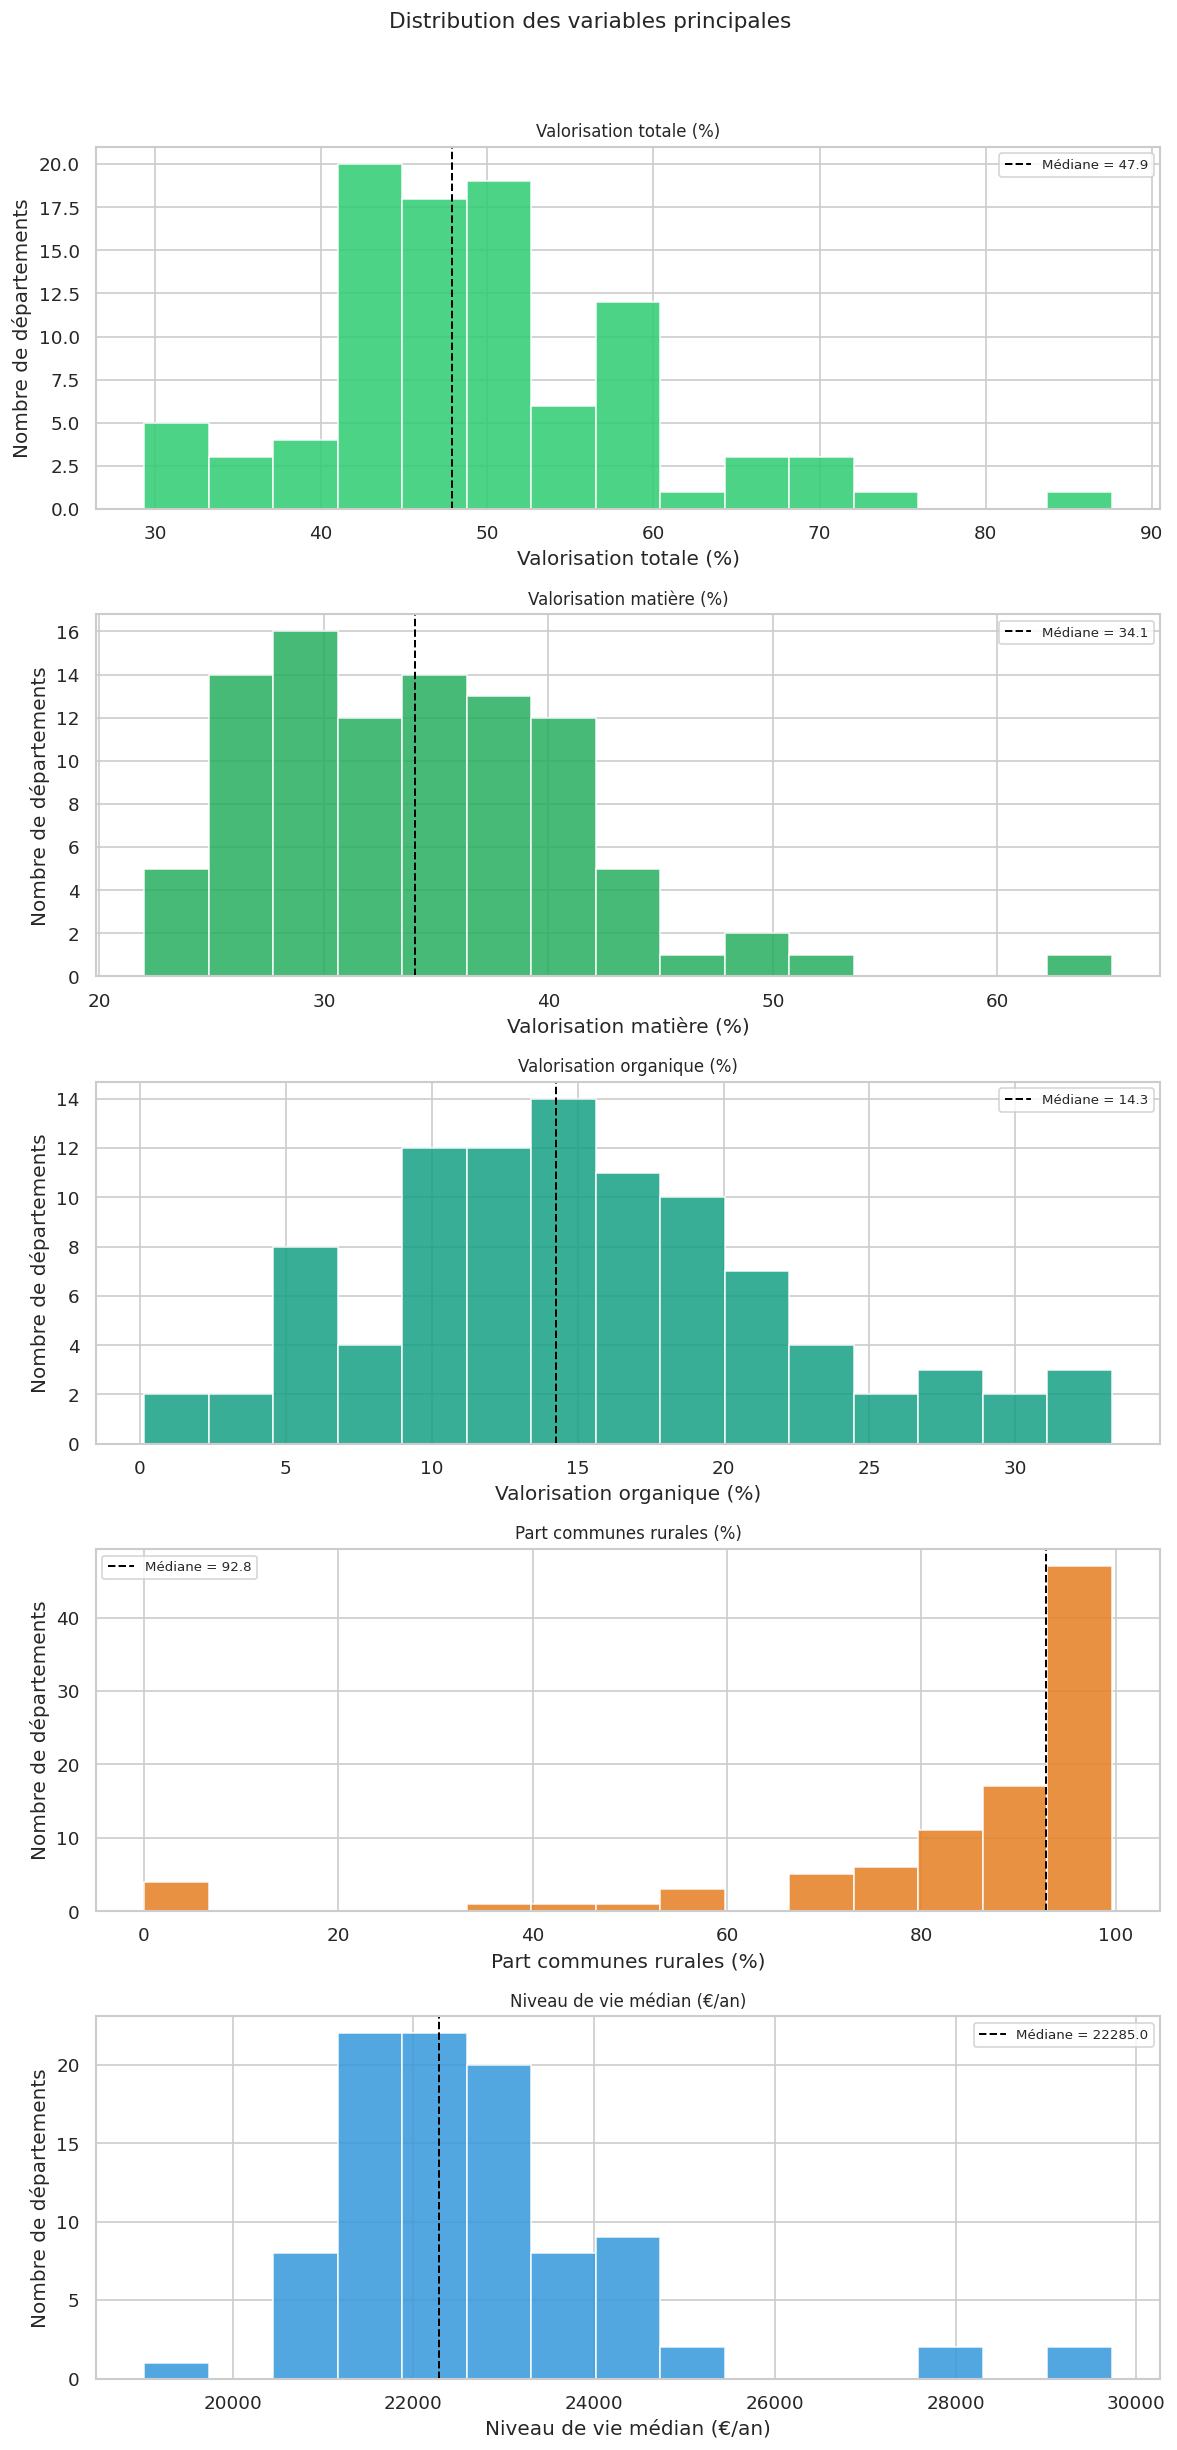

In [29]:
#On fait des histogrammes  (5)
fig, axes = plt.subplots(5, 1, figsize=(10, 20))

for ax, (col, color, label) in zip(axes, configs_distrib):
    # Histogramme de la distribution
    ax.hist(df[col].dropna(), bins=15, color=color, edgecolor="white", alpha=0.85)

    # Ligne verticale de la médiane
    mediane = df[col].median()
    ax.axvline(mediane, color="black", linestyle="--", linewidth=1.2,
               label=f"Médiane = {mediane:.1f}")

    ax.set_title(label, fontsize=10)
    ax.set_xlabel(label)
    ax.set_ylabel("Nombre de départements")
    ax.legend(fontsize=8)

plt.suptitle("Distribution des variables principales", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Analyse :** La distribution du taux de valorisation est relativement symétrique autour de la médiane. La ruralité présente une distribution bimodale (départements très ruraux vs. très urbains), ce qui pourra générer une relation non-linéaire avec la valorisation. Le niveau de vie médian est quant à lui concentré autour d'une plage relativement étroite, avec quelques départements à fort revenu.

### 3.2 Nuages de points : ruralité, niveau de vie et valorisation

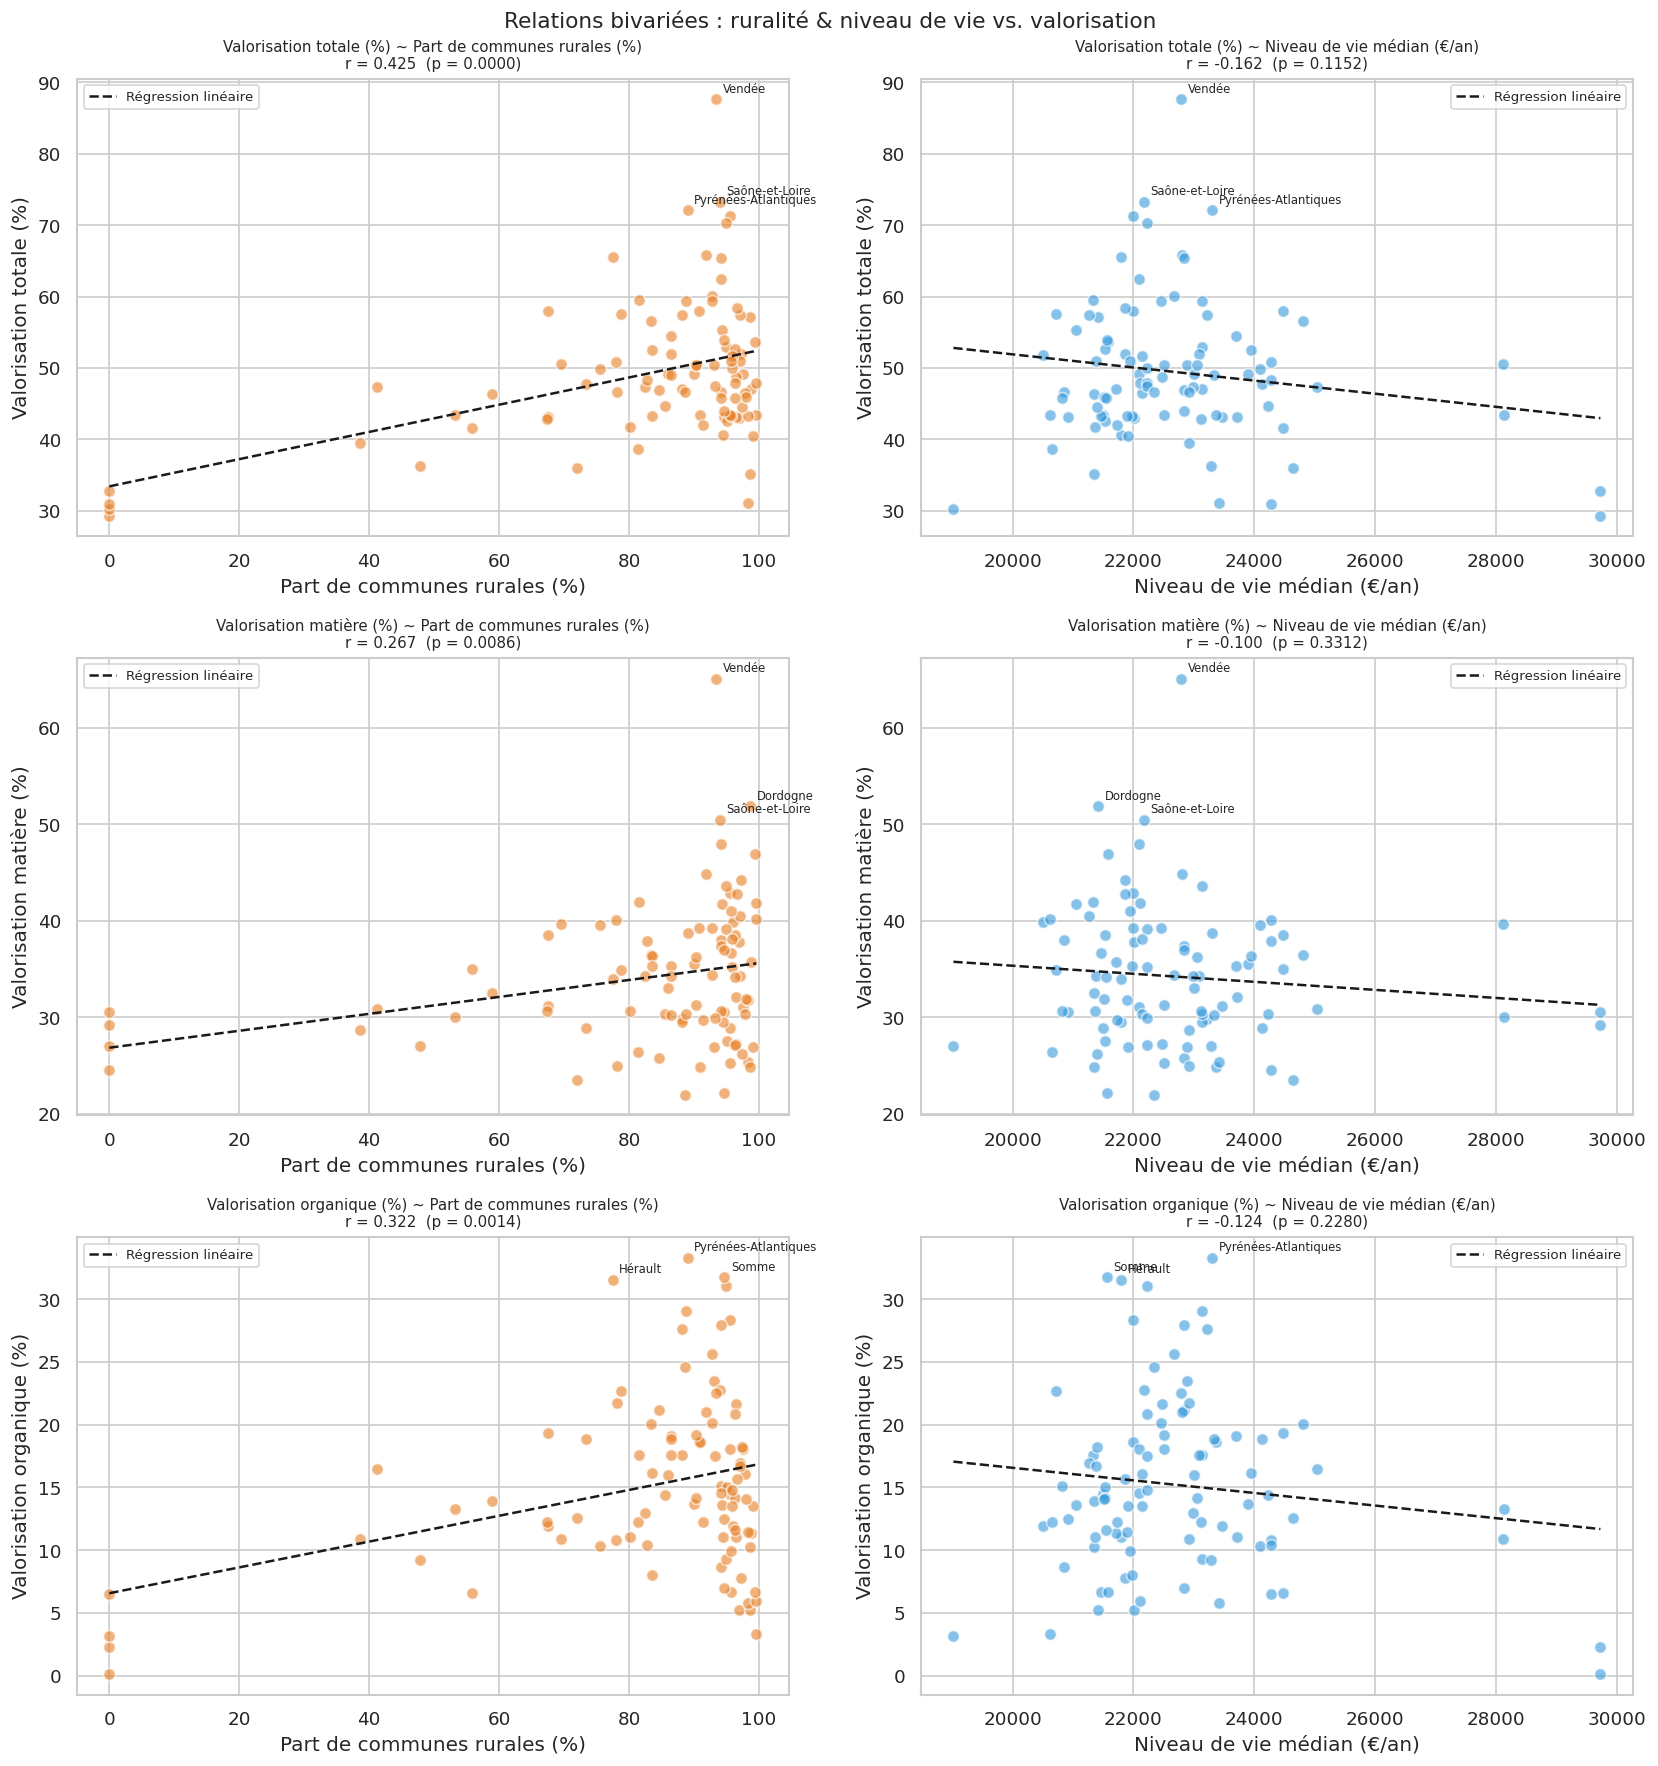

In [30]:
# Grille 3×2 : 3 indicateurs × 2 variables explicatives 
# Lignes : valorisation totale / matière / organique
# Colonnes : ruralité / niveau de vie

fig, axes = plt.subplots(3, 2, figsize=(14, 15))

lignes = [
    ("taux_valo_total_pct",     "Valorisation totale (%)"),
    ("taux_valo_matiere_pct",   "Valorisation matière (%)"),
    ("taux_valo_organique_pct", "Valorisation organique (%)"),
]
colonnes = [
    ("part_communes_rurales_pct", "Part de communes rurales (%)", "#e67e22"),
    ("niveau_vie_median",          "Niveau de vie médian (€/an)", "#3498db"),
]

for i, (y_col, y_label) in enumerate(lignes):
    for j, (x_col, x_label, color) in enumerate(colonnes):
        scatter_regression(axes[i][j],df, x_col, y_col, x_label, y_label, color) 
        axes[i][j].set_xlabel(x_label)
        axes[i][j].set_ylabel(y_label)

plt.suptitle("Relations bivariées : ruralité & niveau de vie vs. valorisation",
             fontsize=13)
plt.tight_layout()
plt.show()

**Analsye :**
- **Ruralité (gauche)** : la droite de régression est  ascendante, confirmant une relation positive entre part de communes rurales et taux de valorisation. Le coefficient de corrélation de Pearson est modéré mais significatif. Cela se retrouve aussi bien pour le total que por les deux types de valorisation.
- **Niveau de vie (droite)** : la pente est quasi-nulle et la p-value dépasse le seuil de 5 %. Il n'y a pas de relation linéaire claire entre le revenu médian et la valorisation des déchets à l'échelle départementale.
- Les départements annotés (outliers) sont ceux dont les résidus sont les plus importants, c'est-à-dire ceux dont le comportement s'écarte le plus de la tendance générale — ils méritent une attention particulière.

### 3.3 Heatmap de corrélation
Petit rappel :
La corrélation de Pearson mesure la "justesse" d'une relation **linéaire** :
 - +1 : relation positive parfaite
 -  0 : aucune relation linéaire
 - −1 : relation négative parfaite



In [31]:
# Calcul de la matrice de corrélation 
vars_corr  = ["taux_valo_total_pct", "taux_valo_matiere_pct", "taux_valo_organique_pct",
              "part_communes_rurales_pct", "niveau_vie_median"]
labels_corr = ["Valo. totale", "Valo. matière", "Valo. organique",
               "Ruralité", "Niveau de vie"]


# dropna() : on retire les départements avec des valeurs manquantes
# pour que toutes les corrélations soient calculées sur le même ensemble, sinon cela ne fonctionne pas et garde des cases blanches
mat_corr = df[vars_corr].dropna().corr().round(3)

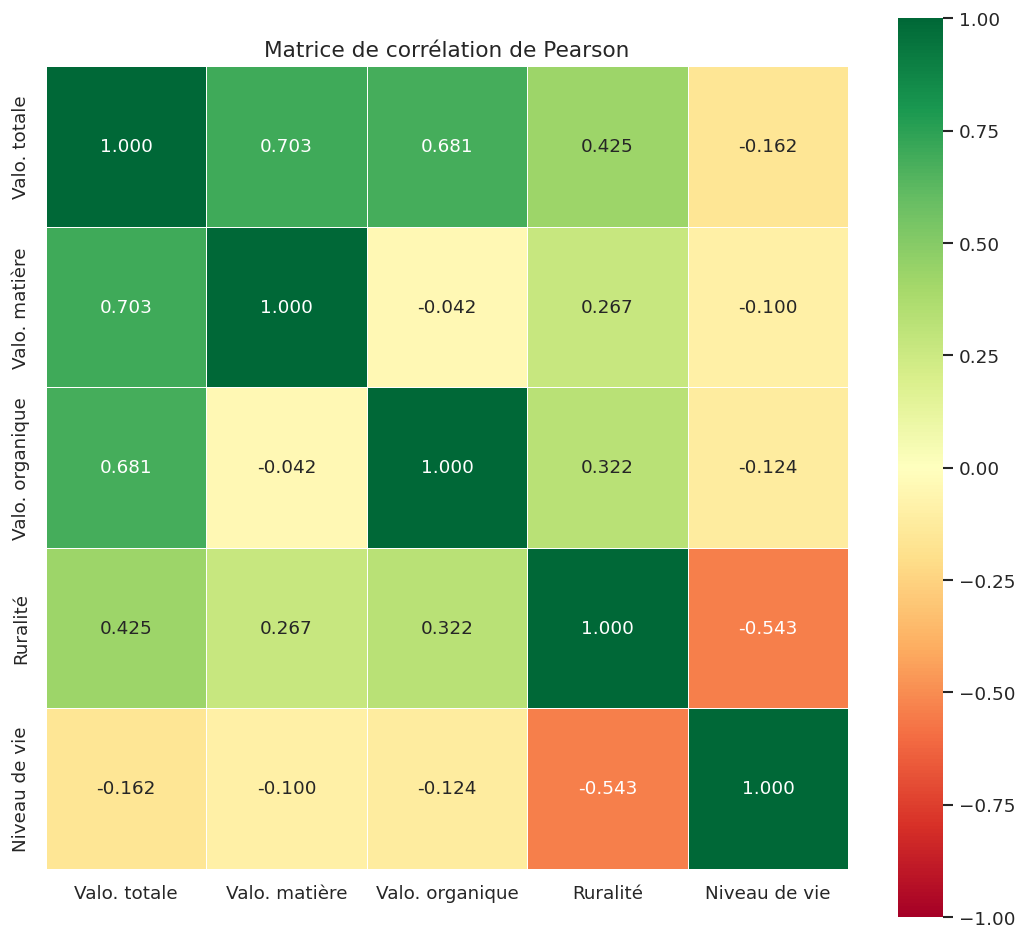

In [32]:
# Affichage de la heatmap 
fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(
    mat_corr,
    annot=True,         
    fmt=".3f",
    cmap="RdYlGn",     
    vmin=-1, vmax=1,
    xticklabels=labels_corr,
    yticklabels=labels_corr,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 11},  # taille des valeurs dans les cellules
    ax=ax,
)
#  annot permet de mettre les valeurs dans les cases et cmap est définit pour que le rouge soit pour le négatif et le vert pour le positif
ax.set_title("Matrice de corrélation de Pearson", fontsize=13)
ax.tick_params(axis="x", labelsize=11)  
ax.tick_params(axis="y", labelsize=11) 
plt.tight_layout()
plt.show()

**Lecture :** La heatmap confirme que la corrélation la plus forte avec le taux de valorisation est celle de la ruralité (valeur positive modérée). On note également une corrélation négative entre ruralité et niveau de vie — les départements ruraux sont en moyenne moins riches — ce qui soulève un risque de **colinéarité partielle** entre les deux variables explicatives. Ce point sera discuté dans la régression multiple.

### 3.4 Analyse cartographique : les cartes choroplèthes

Rappel : Une carte choroplèthe colorie chaque département selon l'intensité d'une variable : plus la couleur est foncée, plus la valeur est élevée.

In [33]:
# Chargement du fond de carte 
# Le GeoJSON contient les contours géographiques des 96 départements métropolitains.
carte_base = gpd.read_file(GEOJSON_URL)

# Harmonisation du code pour la jointure
carte_base["code"] = carte_base["code"].astype(str).str.zfill(2)
df["code_dept"]    = df["code_dept"].astype(str).str.zfill(2)

# Jointure : on enrichit chaque polygone géographique avec nos données
carte = carte_base.merge(df, left_on="code", right_on="code_dept", how="left")
print(f"Carte chargée : {len(carte)} départements")

Carte chargée : 96 départements


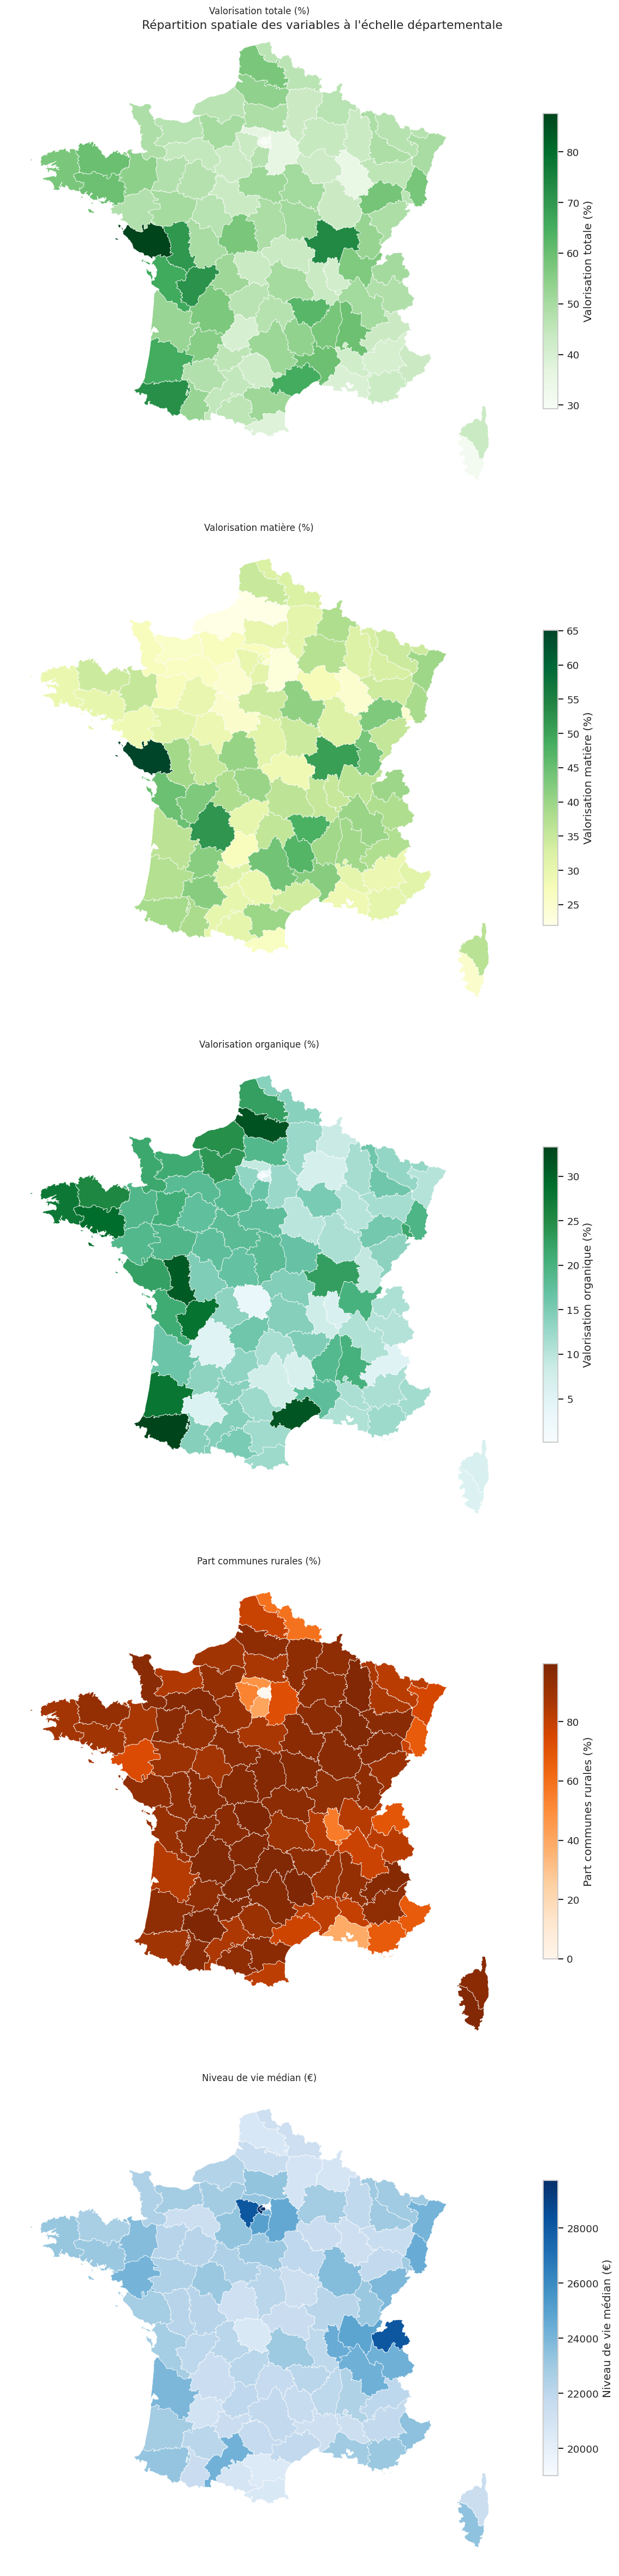

In [34]:
# Cartes choroplèthes : 5 variables l'une après l'autre
configs_cartes = [
    ("taux_valo_total_pct",       "Greens",  "Valorisation totale (%)"),
    ("taux_valo_matiere_pct",     "YlGn",    "Valorisation matière (%)"),
    ("taux_valo_organique_pct",   "BuGn",    "Valorisation organique (%)"),
    ("part_communes_rurales_pct", "Oranges", "Part communes rurales (%)"),
    ("niveau_vie_median",         "Blues",   "Niveau de vie médian (€)"),
]

fig, axes = plt.subplots(5, 1, figsize=(10, 40))

for ax, (col, cmap, title) in zip(axes, configs_cartes):
    carte.plot(
        column=col,
        cmap=cmap,
        linewidth=0.4,
        edgecolor="white",
        legend=True,
        legend_kwds={"shrink": 0.6, "label": title},
        ax=ax,
        missing_kwds={"color": "lightgrey", "label": "Donnée manquante"},
    )
    ax.set_title(title, fontsize=10)
    ax.axis("off")   

plt.suptitle("Répartition spatiale des variables à l'échelle départementale",
             fontsize=13)
plt.tight_layout()
plt.show()

**Lecture des cartes :**
- La carte de valorisation (verte) révèle une **concentration des bons performeurs dans les zones rurales** (diagonale nord-est / sud-ouest et Massif Central), alors que les grandes métropoles et leurs couronnes affichent des taux plus faibles.
- La carte de ruralité (orange) montre une structure spatiale similaire, ce qui renforce visuellement la corrélation positive entre les deux variables.
- La carte de niveau de vie (bleue) présente un gradient différent, plus concentré autour de l'Île-de-France et de quelques métropoles. Sa géographie est donc **distincte** de celle de la valorisation, cohérent avec l'absence de corrélation significative observée statistiquement.

### 3.5 Carte typologique : 4 profils territoriaux

 On croise deux dimensions binaires :
 - Rural / Urbain (au-dessus / en-dessous de la médiane nationale de ruralité)
 - Valorisation forte / faible (au-dessus / en-dessous de la médiane nationale)

 On identifie 4 profils : les cas "rural / valorisation faible" sont particulièrement intéressants car ils montrent que la ruralité seule ne suffit pas.


In [35]:
#  Calcul des seuils (médianes nationales) 
med_valo  = df["taux_valo_total_pct"].median()
med_rural = df["part_communes_rurales_pct"].median()

ordre_profils = [
    "Urbain / valorisation faible",
    "Urbain / valorisation forte",
    "Rural  / valorisation faible",
    "Rural  / valorisation forte",
]
df["profil"] = pd.Categorical(
    df.apply(lambda row: attribuer_profil(row, med_valo, med_rural), axis=1),
    categories=ordre_profils,
    ordered=True,
)

print(f"Seuil valorisation : {med_valo:.1f}%")
print(f"Seuil ruralité     : {med_rural:.1f}%")

Seuil valorisation : 47.9%
Seuil ruralité     : 92.8%


In [36]:
#On complete les profils 
print("Répartition des profils :")
display(df["profil"].value_counts().rename("Nombre de départements").to_frame())


Répartition des profils :


,Nombre de départements
profil,
Urbain / valorisation faible,25
Rural / valorisation forte,25
Urbain / valorisation forte,23
Rural / valorisation faible,23


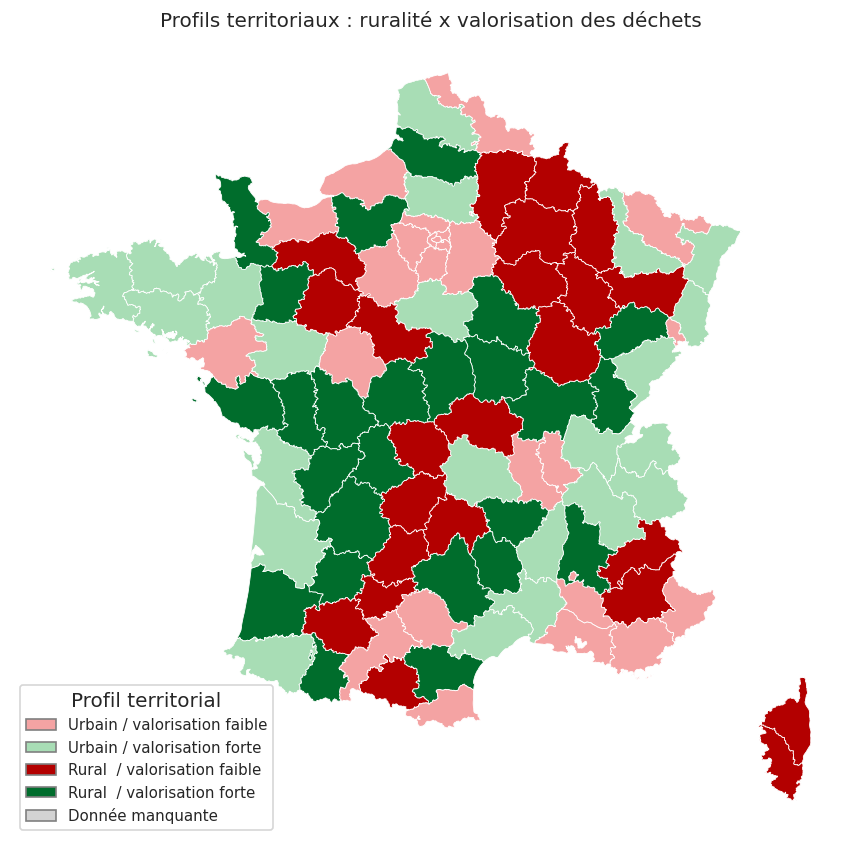

In [37]:
#  On trace la carte typologique
# Palette : rouge/vert selon la valorisation, clair/foncé selon la ruralité
couleurs_profil = {
    "Urbain / valorisation faible": "#f4a3a3",  # rose clair
    "Urbain / valorisation forte":  "#a8ddb5",  # vert clair
    "Rural  / valorisation faible": "#b30000",  # rouge foncé
    "Rural  / valorisation forte":  "#006d2c",  # vert foncé
}

# Rechargement de la carte avec la colonne profil
carte2 = carte_base.merge(df, left_on="code", right_on="code_dept", how="left")
carte2["couleur"] = carte2["profil"].map(couleurs_profil)

fig, ax = plt.subplots(figsize=(9, 10))

# On passe color= (discret) et non column= (gradient continu)
carte2.plot(
    color=carte2["couleur"].astype(object).fillna("lightgrey"),
    linewidth=0.5,
    edgecolor="white",
    ax=ax,
)

# Légende manuelle avec des patches colorés
patches = [
    mpatches.Patch(facecolor=v, edgecolor="grey", label=k)
    for k, v in couleurs_profil.items()
]
patches.append(mpatches.Patch(facecolor="lightgrey", edgecolor="grey",
                               label="Donnée manquante"))
ax.legend(handles=patches, title="Profil territorial",
          loc="lower left", frameon=True, fontsize=9)
ax.set_title("Profils territoriaux : ruralité x valorisation des déchets",
             fontsize=12)
ax.axis("off")
plt.show()

**Analyse :**
La carte fait ressortir une concentration des profils "rural / valorisation forte" (vert foncé) dans les zones à forte tradition agricole (Massif Central, Bretagne intérieure, Grand Est rural). Les profils "rural / valorisation faible" (rouge foncé) sont des cas d'exception cependant la ruralité seule ne garantit pas de bonnes performances, d'autres facteurs comme l'organisation des filières ou la densité d'équipements jouent un rôle. Les profils urbains sont plus dispersés géographiquement. 

### 3.6 Clustering K-Means

Le clustering regroupe automatiquement les départements en profils similaires,
sans définir de seuils à la main (contrairement à la carte typologique).

On utilise **K-Means** sur 3 variables : valorisation totale, ruralité, niveau de vie.

In [38]:

# Sélection des variables et suppression des valeurs manquantes
X = df[["taux_valo_total_pct", "part_communes_rurales_pct", "niveau_vie_median"]].dropna()

In [39]:
# Normalisation obligatoire pour K-Means
#car sinon niveau_vie_median (20 000-30 000 €) écraserait les autres variables (0-100 %)
# StandardScaler : transforme chaque variable pour avoir moyenne=0 et écart-type=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

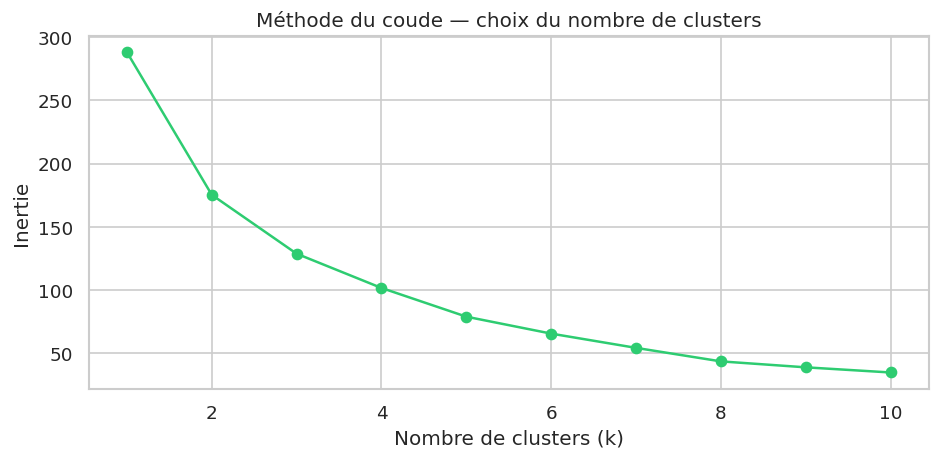

In [40]:
# Méthode du coude : on teste k=1 à 10 et on trace l'inertie
# L'inertie mesure la dispersion interne des clusters — plus elle est basse, mieux c'est
# On cherche le "coude" : le point où l'inertie cesse de baisser fortement
inerties = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inerties.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inerties, marker="o", color="#2ecc71")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie")
plt.title("Méthode du coude — choix du nombre de clusters")
plt.tight_layout()
plt.show()

**Lecture du graphique :** La courbe marque un coude visible autour de **k=3 ou k=4**.
On retient **k=4** pour pouvoir comparer directement avec les 4 profils manuels
de la section 3.5 (urbain/rural × valorisation forte/faible).

In [41]:
# On choisit k=4 pour comparer avec nos 4 profils manuels de la carte typologique
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df.loc[X.index, "cluster"] = kmeans.fit_predict(X_scaled)
df["cluster"] = df["cluster"].astype("Int64")  
# Int64 gère les NaN

In [42]:
# Profil moyen de chaque cluster
# Permet de comprendre ce qui caractérise chaque groupe
display(
    df.groupby("cluster")[["taux_valo_total_pct", "part_communes_rurales_pct",
                            "niveau_vie_median"]]
    .mean().round(2)
)

,taux_valo_total_pct,part_communes_rurales_pct,niveau_vie_median
cluster,,,
0,46.48,90.30,22385.94
1,39.03,30.70,28925.00
2,63.07,89.81,22382.73
3,37.66,30.59,23170.00


**Lecture des clusters :**
- **Cluster 0** : départements ruraux à forte valorisation organique — correspondent aux profils "rural / valorisation forte"
- **Cluster 1** : départements urbains à faible valorisation — grandes métropoles
- **Cluster 2** : départements intermédiaires — ni très ruraux ni très urbains
- **Cluster 3** : départements ruraux à faible valorisation organique malgré la ruralité


**Lecture des clusters :**

| Cluster | Profil | Caractéristiques |
|---|---|---|
| 0 | Rural / valorisation moyenne | Très rural (90%), revenu faible (22 386€), valorisation intermédiaire (46%) |
| 1 | Urbain / riche / faible valorisation | Peu rural (31%), revenu élevé (28 925€), valorisation faible (39%) |
| 2 | Rural / valorisation forte | Très rural (90%), revenu faible (22 383€), valorisation élevée (63%) |
| 3 | Urbain / pauvre / faible valorisation | Peu rural (31%), revenu moyen (23 170€), valorisation très faible (38%) |

**Enseignements :**

- Les clusters 0 et 2 sont tous les deux très ruraux et ont des niveaux de vie quasi identiques — c'est donc bien **l'organisation des filières de tri** qui explique la différence de valorisation entre eux, pas la ruralité ni le revenu.
- Les clusters 1 et 3 sont tous les deux urbains mais avec des niveaux de vie différents — et pourtant leurs taux de valorisation sont similaires (~38-39%), ce qui **confirme que le revenu n'est pas déterminant**.
- Ce résultat renforce les conclusions de la régression : la ruralité joue un rôle mais n'est pas suffisante seule.



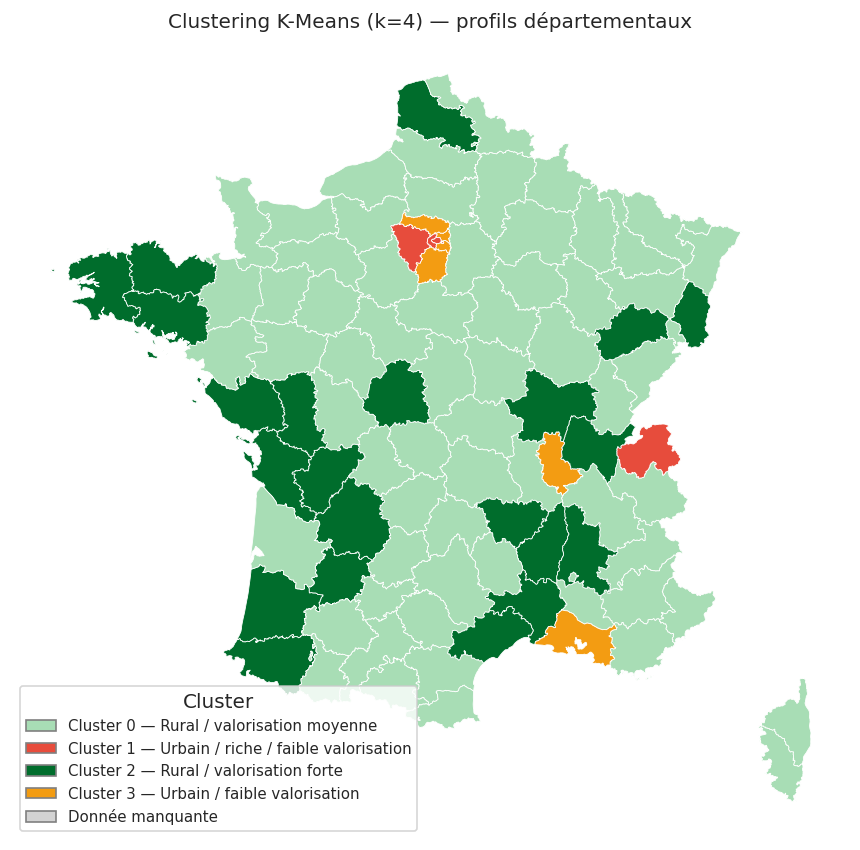

In [43]:
# Carte choroplèthe des clusters avec couleurs personnalisées
carte3 = carte_base.merge(df[["code_dept", "cluster"]], 
                           left_on="code", right_on="code_dept", how="left")

# Palette manuelle : une couleur par cluster selon le profil
# vert foncé = rural fort, vert clair = rural moyen, jaune = rural faible, rouge = urbain faible


palette_clusters = {
    "0": "#a8ddb5",   # vert clair  — rural / valorisation moyenne
    "1": "#e74c3c",   # rouge       — urbain / riche / faible valorisation
    "2": "#006d2c",   # vert foncé  — rural / valorisation forte
    "3": "#f39c12",   # jaune/orange — urbain / faible valorisation
}

carte3["cluster"] = carte3["cluster"].astype(str)
carte3["couleur"] = carte3["cluster"].map(palette_clusters)

fig, ax = plt.subplots(figsize=(9, 10))
carte3.plot(
    color=carte3["couleur"].astype(object).fillna("lightgrey"),
    linewidth=0.5,
    edgecolor="white",
    ax=ax,
)

# Légende manuelle
import matplotlib.patches as mpatches
labels = {
    "0": "Cluster 0 — Rural / valorisation moyenne",
    "1": "Cluster 1 — Urbain / riche / faible valorisation",
    "2": "Cluster 2 — Rural / valorisation forte",
    "3": "Cluster 3 — Urbain / faible valorisation",
}
patches = [
    mpatches.Patch(facecolor=palette_clusters[k], edgecolor="grey", label=v)
    for k, v in labels.items()
]
patches.append(mpatches.Patch(facecolor="lightgrey", edgecolor="grey", label="Donnée manquante"))
ax.legend(handles=patches, title="Cluster", loc="lower left", frameon=True, fontsize=9)

ax.set_title("Clustering K-Means (k=4) — profils départementaux", fontsize=12)
ax.axis("off")
plt.show()



**Analyse de la carte des clusters :**

**Cluster 0 (vert clair) — Rural / valorisation moyenne**
Très majoritaire, couvre la diagonale du vide (Massif Central, Normandie, Grand Est rural).
Ce sont les départements ruraux "standard" avec une valorisation correcte (46%) mais pas exceptionnelle. Très ruraux (90%) et revenu modeste (22 386€).

**Cluster 2 (vert foncé) — Rural / valorisation forte**
Concentré en Bretagne, Pays de la Loire, et plusieurs départements du Sud-Ouest et du Centre. Ce sont les meilleurs élèves avec un taux de valorisation de 63%, pourtant même niveau de ruralité (90%) et de revenu (22 383€) que le cluster 0.
C'est donc bien l'organisation des filières locales qui fait la différence, pas la ruralité ni le revenu.

**Cluster 1 (rouge) — Urbain / riche / faible valorisation**
Visible uniquement sur Paris et sa couronne, plus quelques départements frontaliers. Revenu élevé (28 925€) mais valorisation faible (39%) — confirme que la richesse ne favorise pas le recyclage. 

**Cluster 3 (jaune) — Urbain / revenu intermédiaire / faible valorisation**
Quelques départements isolés (Hérault, Var). Peu ruraux (31%), revenu moyen (23 170€), valorisation très faible (38%).

**Ce que la carte confirme :**
- La géographie de la valorisation suit largement la géographie rurale
- Les clusters 0 et 2 ont exactement le même profil territorial et socio-économique mais des performances très différentes → la ruralité seule ne suffit pas
- La concentration urbaine est un frein à la valorisation, indépendamment du revenu

## 4. Modélisation

### 4.1 Corrélations bivariées

In [44]:
# Corrélations : ruralité vs les 3 indicateurs 
print("=" * 60)
print("RURALITÉ X VALORISATION")
print("=" * 60)
afficher_correlations(df,"part_communes_rurales_pct", "taux_valo_total_pct",
                      "Ruralité", "Valorisation totale")
afficher_correlations(df,"part_communes_rurales_pct", "taux_valo_matiere_pct",
                      "Ruralité", "Valorisation matière")
afficher_correlations(df,"part_communes_rurales_pct", "taux_valo_organique_pct",
                      "Ruralité", "Valorisation organique")


RURALITÉ X VALORISATION
  Ruralité × Valorisation totale
  Pearson  r = 0.425  (p = 0.000016)
  Spearman ρ = 0.139  (p = 0.177203)
  → significatif au seuil 5 %

  Ruralité × Valorisation matière
  Pearson  r = 0.267  (p = 0.008607)
  Spearman ρ = 0.227  (p = 0.026364)
  → significatif au seuil 5 %

  Ruralité × Valorisation organique
  Pearson  r = 0.322  (p = 0.001376)
  Spearman ρ = -0.046  (p = 0.654252)
  → significatif au seuil 5 %



In [45]:
# Corrélations : niveau de vie vs les 3 indicateurs 
print("=" * 60)
print("NIVEAU DE VIE X VALORISATION")
print("=" * 60)
afficher_correlations(df,"niveau_vie_median", "taux_valo_total_pct",
                      "Niveau de vie", "Valorisation totale")
afficher_correlations(df,"niveau_vie_median", "taux_valo_matiere_pct",
                      "Niveau de vie", "Valorisation matière")
afficher_correlations(df,"niveau_vie_median", "taux_valo_organique_pct",
                      "Niveau de vie", "Valorisation organique")

NIVEAU DE VIE X VALORISATION
  Niveau de vie × Valorisation totale
  Pearson  r = -0.162  (p = 0.115179)
  Spearman ρ = -0.028  (p = 0.784731)
  → non significatif au seuil 5 %

  Niveau de vie × Valorisation matière
  Pearson  r = -0.100  (p = 0.331167)
  Spearman ρ = -0.134  (p = 0.191642)
  → non significatif au seuil 5 %

  Niveau de vie × Valorisation organique
  Pearson  r = -0.124  (p = 0.228036)
  Spearman ρ = 0.062  (p = 0.547383)
  → non significatif au seuil 5 %



**Interprétation :** La ruralité est significativement corrélée à la valorisation (Pearson et Spearman concordants). Le niveau de vie ne l'est pas. On note également que ruralité et niveau de vie sont négativement corrélés : les territoires ruraux ont tendance à être moins riches. Cette structure de corrélation sera à surveiller dans la régression multiple.

**Point d'attention Pour ruralité x Valorisation** : la corrélation de Pearson (r = 0.425, p < 0.001)  et celle de Spearman (ρ = 0.139, p = 0.177) donnent des conclusions opposées. Cela s'explique par la forme de la relation : Pearson capte l'association linéaire, Spearman l'association monotone sur les rangs.

Le résultat de Spearman pose question : la relation n'est pas robuste sur l'ensemble de la distribution. C'est une raison supplémentaire pour interpréter le modèle de régression avec nuance.

### 4.2 Régression Régressions OLS — les trois indicateurs séparément

On estime trois modèles emboîtés pour évaluer l'apport de chaque variable :
- **Modèle 1** : ruralité seule
- **Modèle 2** : ruralité + niveau de vie
- **Modèle 3** : ruralité + niveau de vie + **terme d'interaction** (ruralité × niveau de vie, centré)

Le terme d'interaction teste si l'effet de la ruralité sur la valorisation **varie selon le niveau de richesse du département**.

In [46]:
# Régression sur la valorisation TOTALE 
mod1_tot, mod2_tot, mod3_tot = regression_ols(df, "taux_valo_total_pct", "Valorisation totale (%)")


RÉGRESSION OLS — Valorisation totale (%)
                      Modèle 1 (ruralité) Modèle 2 (+revenu) Modèle 3 (+interaction)
Part communes rurales          0.1906 (*)         0.2144 (*)            -0.1775 (ns)
Niveau de vie médian                    —        0.0006 (ns)            -0.0003 (ns)
Interaction                             —                  —             0.0000 (ns)
R²                                  0.180              0.187                   0.200
R² ajusté                           0.172              0.170                   0.174
* = significatif à 5 % | ns = non significatif


In [47]:
# Régression sur la valorisation MATIÈRE 
mod1_mat, mod2_mat, mod3_mat = regression_ols(df,"taux_valo_matiere_pct", "Valorisation matière / recyclage (%)")



RÉGRESSION OLS — Valorisation matière / recyclage (%)
                      Modèle 1 (ruralité) Modèle 2 (+revenu) Modèle 3 (+interaction)
Part communes rurales          0.0877 (*)         0.0991 (*)             0.2235 (ns)
Niveau de vie médian                    —        0.0003 (ns)             0.0005 (ns)
Interaction                             —                  —            -0.0000 (ns)
R²                                  0.071              0.074                   0.076
R² ajusté                           0.061              0.054                   0.046
* = significatif à 5 % | ns = non significatif


In [48]:
#  Régression sur la valorisation ORGANIQUE 
mod1_org, mod2_org, mod3_org = regression_ols(df,"taux_valo_organique_pct","Valorisation organique / compostage (%)")



RÉGRESSION OLS — Valorisation organique / compostage (%)
                      Modèle 1 (ruralité) Modèle 2 (+revenu) Modèle 3 (+interaction)
Part communes rurales          0.1029 (*)         0.1154 (*)            -0.4010 (ns)
Niveau de vie médian                    —        0.0003 (ns)            -0.0008 (ns)
Interaction                             —                  —              0.0000 (*)
R²                                  0.104              0.107                   0.150
R² ajusté                           0.094              0.088                   0.123
* = significatif à 5 % | ns = non significatif


**Interprétation des modèles : **


**Valorisation totale**
**Modèle 1** : La ruralité seule explique 18 % de la variance du taux de valorisation total (R² = 0.180, R² ajusté = 0.172). Le coefficient est positif et significatif (β = 0.191, p < 0.05) : une hausse d'un point de la part de communes rurales est associée à +0.19 pt de taux de valorisation.
**Modèle 2** : L'ajout du niveau de vie n'améliore pas le modèle — le R² ajusté recule (0.172 → 0.170). Le niveau de vie reste non significatif (p > 0.05). La ruralité reste le seul facteur explicatif.
**Modèle 3** : L'interaction n'est pas significative. Le R² ajusté remonte légèrement à 0.174 mais reste modéré. Le modèle 1 reste le plus parcimonieux.


**Valorisation matière (recyclage)**
**Modèle 1** : La ruralité explique seulement 7 % de la variance (R² = 0.071, R² ajusté = 0.061) — bien moins que pour la valorisation totale. La relation est significative mais faible (β = 0.088).
**Modèle 2 et 3** : Le R² ajusté diminue à chaque ajout de variable (0.061 → 0.054 → 0.046). Cela confirme que ni le niveau de vie ni l'interaction n'apportent d'information utile. Le recyclage dépend probablement davantage des infrastructures locales (déchèteries, collecte sélective) que des caractéristiques territoriales mesurées ici.

**Valorisation organique (compostage)**
**Modèle 1** : La ruralité explique 10 % de la variance (R² = 0.104, R² ajusté = 0.094). C'est cohérent avec l'hypothèse territoriale — le compostage est une pratique que l'on peut considérer comme davantage répandue en milieu rural.
**Modèle 3** : Résultat notable — le terme d'interaction est significatif (p < 0.05) avec un R² ajusté de 0.123. Cela signifie que l'effet de la ruralité sur la valorisation organique varie selon le niveau de vie : dans les départements ruraux riches, le compostage est encore plus développé que dans les départements ruraux pauvres.

**Conclusion** : La ruralité est le principal facteur explicatif, porté essentiellement par la valorisation organique. Le recyclage (valorisation matière) est peu sensible aux variables territoriales testées ici, ce qui suggère que d'autres facteurs — densité de déchèteries, politiques locales — jouent un rôle plus important pour cette composante.

### 4.3 Vérification des hypothèses du modèle OLS

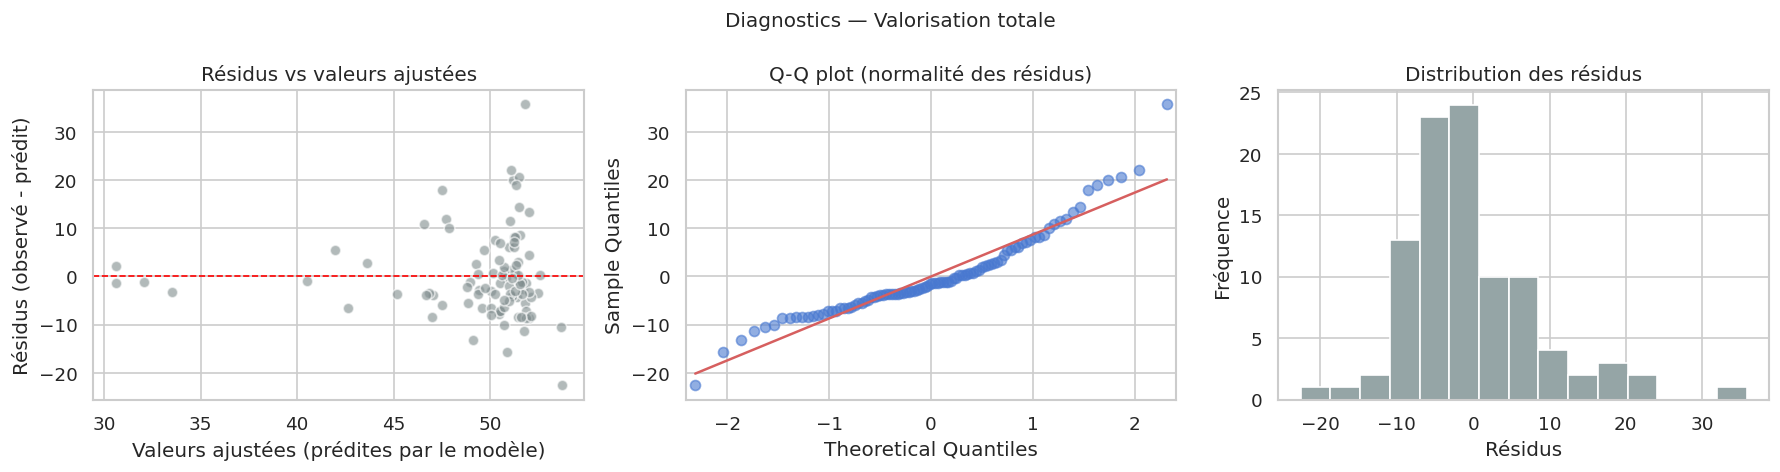

Shapiro-Wilk : W = 0.9225, p = 0.0000
→ Résidus non normaux (p < 0.05) — interpréter les IC avec prudence


In [49]:
# Diagnostics — valorisation totale
diagnostics_ols(mod3_tot, "Valorisation totale")


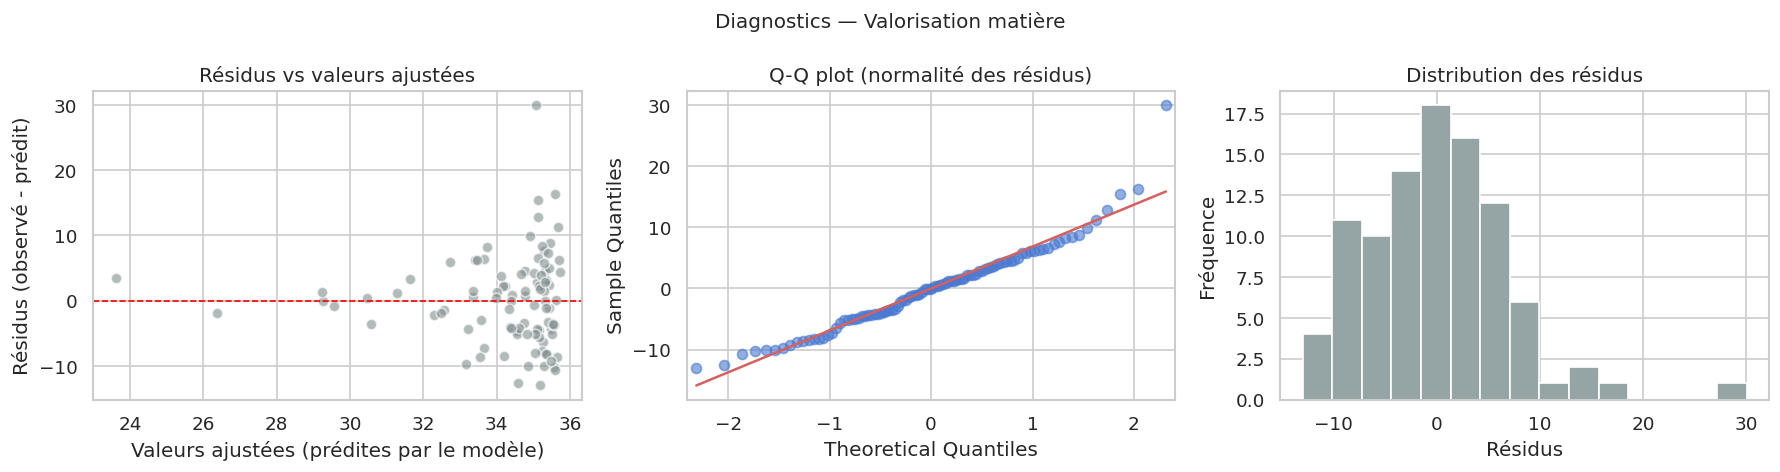

Shapiro-Wilk : W = 0.9522, p = 0.0015
→ Résidus non normaux (p < 0.05) — interpréter les IC avec prudence


In [50]:
#  Diagnostics — valorisation matière 
diagnostics_ols(mod3_mat, "Valorisation matière")


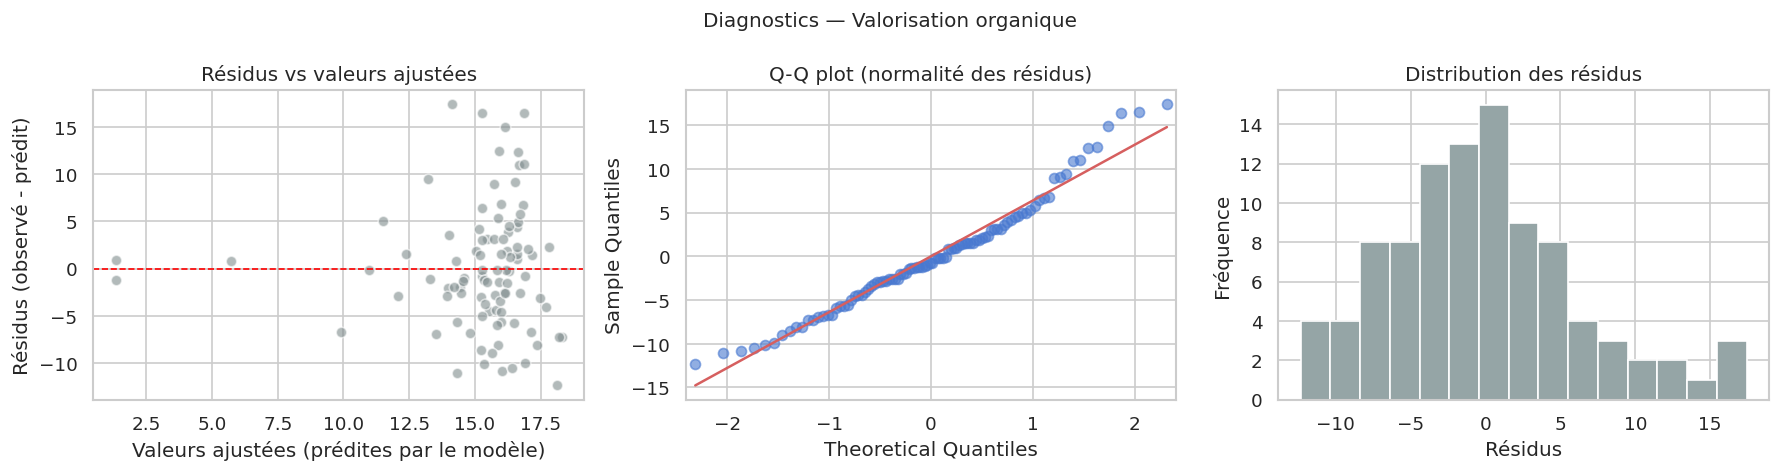

Shapiro-Wilk : W = 0.9686, p = 0.0211
→ Résidus non normaux (p < 0.05) — interpréter les IC avec prudence


In [51]:
#  Diagnostics — valorisation organique 
diagnostics_ols(mod3_org, "Valorisation organique")


**Lecture des diagnostics :**
- *Résidus vs valeurs ajustées* : le nuage est globalement centré sur 0 mais quelques points extrêmes en haut à gauche (forts résidus positifs pour les hauts taux de valorisation) signalent une légère hétéroscédasticité.
- *Q-Q plot* : les queues s'écartent de la diagonale, surtout à droite — quelques départements outliers (Vendée, Saône-et-Loire) tirent la distribution vers le haut.
- *Shapiro-Wilk* : W = 0.9225, p < 0.001 → on rejette la normalité. Les p-values et intervalles de confiance de la régression sont donc à interpréter avec prudence. Une solution serait de tester une transformation log du taux de valorisation ou d'utiliser des erreurs standard robustes.

## 5. Conclusion générale

Cette étude avait pour objectif d'identifier les facteurs territoriaux et socio-économiques associés à la valorisation des déchets ménagers à l'échelle départementale en France.

**Principaux résultats :**

1. **La ruralité est positivement et significativement associée au taux de valorisation.** Cette relation se confirme à travers l'analyse descriptive, les corrélations, les cartes choroplèthes et la régression. Elle peut s'expliquer par une plus grande pratique du compostage et de la valorisation organique en milieu rural, ainsi qu'une moindre densité de déchets à gérer.

2. **Le niveau de vie médian n'est pas un déterminant significatif.** L'absence de relation entre revenu et valorisation suggère que les performances en matière de recyclage ne sont pas davantage le fait des territoires riches, mais qu'elles dépendent davantage de l'organisation territoriale.

3. **Le terme d'interaction n'est pas significatif** (p = 0.233) : l'effet de la ruralité sur la valorisation est indépendant du niveau de richesse du département. Les territoires ruraux pauvres et les territoires ruraux aisés valorisent leurs déchets dans des proportions similaires.



**Limites :**
- L'indicateur de ruralité n'est pas pondéré par la population, ce qui sur-représente les communes faiblement peuplées.
- Le modèle explique une part limitée de la variance (R² modéré) : d'autres facteurs (densité d'équipements, politiques locales, part de maisons individuelles avec jardin) mériteraient d'être intégrés.
- L'analyse est transversale (une seule année) : une approche longitudinale permettrait de contrôler des effets fixes départementaux.

**Pistes d'approfondissement :** intégration d'indicateurs de mobilité verte, de densité de déchèteries, ou de la part de logements individuels, evolution dans le temps.